In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [3]:
root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_test'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide_512'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide_2'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/01_ex_con_2025_full_wide_ltor'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/02_ex_con_2025_full_wide_ltor_beta_2times'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/02_ex_con_2025_full_gheart'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/03_ex_con_2025_full_gheart_weibull'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/04_ex_con_2025_full_gheart_l

In [4]:
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

In [9]:
scenario_name = "09_ex_con_2025_full_logit_mean_one"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [6]:
vars = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0',  'root_area_index', 'wcont_sigma_deviation','g_stem_res', 'vmax25' , 'jmax25']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0','jackson_root_beta']

In [7]:
post_path

'/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/10_ex_con_2025_full_logit_mean_one/post'

In [10]:
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.05]
df_grp = df.groupby(['id'])[vars].mean()

In [15]:
df

,Unnamed: 0,index,id,root_area_index,canopy_height,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
37470,0,5739,7494,7.187782,35,1800.0,1800,False,1.0,1.75,...,0.573055,0.145674,0.530569,0.438917,0.617072,0.540089,0.462336,0.860434,0.963200,0
37471,1,4219,7494,10.240082,35,1800.0,1800,False,1.0,1.75,...,6.790228,8.385908,4.229049,4.458288,4.208653,4.142723,4.858002,0.860434,0.963200,1
37474,4,9390,7494,7.182587,35,1800.0,1800,False,1.0,1.75,...,6.189416,6.353562,3.990708,4.246165,3.967208,3.945400,4.380721,0.860434,0.963200,4
37473,3,4928,7494,8.994954,35,1800.0,1800,False,1.0,1.75,...,6.393250,6.558569,3.856413,4.098621,3.828995,3.808748,4.292354,0.860434,0.963200,3
37472,2,8481,7494,7.470569,35,1800.0,1800,False,1.0,1.75,...,1.805595,2.046385,1.116165,1.238138,1.079382,1.007822,1.267966,0.860434,0.963200,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39166,1,9373,7833,11.287356,35,1800.0,1800,False,1.0,1.75,...,7.264851,7.434421,4.071020,4.290366,4.051098,3.962547,4.579697,0.834413,1.049898,1
39168,3,3796,7833,13.656294,35,1800.0,1800,False,1.0,1.75,...,6.305556,6.470379,3.751933,3.982014,3.729019,3.706041,4.187819,0.834413,1.049898,3
39165,0,263,7833,11.946080,35,1800.0,1800,False,1.0,1.75,...,0.628952,0.132290,0.583823,0.499891,0.658489,0.570807,0.503951,0.834413,1.049898,0
39169,4,4044,7833,10.894610,35,1800.0,1800,False,1.0,1.75,...,6.257923,6.422472,4.030031,4.286320,4.008279,3.985877,4.424756,0.834413,1.049898,4


In [11]:
df.loc[df['sid'] == 3,'sid']= 4
df.loc[df['sid'] == 2,'sid']= 3
df['sid']

42560    0
42561    1
42562    3
42564    4
42563    4
        ..
94927    3
94925    0
94929    4
94926    1
94928    4
Name: sid, Length: 5845, dtype: int64

In [12]:
dead_ids =[0,3,6,7]
dfs =df[df['sid'] == 0]
dfs.sort_values(by=['alive_mean'], inplace=True, ascending=True)
dfs.to_csv(os.path.join(post_path, "Alive.csv"))
for i in range(1,5):
    dfs =df[df['sid'] == i]
    dfs.sort_values(by=[f't{dead_ids[i - 1]}'], inplace=True, ascending=True)
    dfs.to_csv(os.path.join(post_path, f"Dead{i}.csv"))

/tmp/ipykernel_2353462/984454782.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs.sort_values(by=['alive_mean'], inplace=True, ascending=True)
/tmp/ipykernel_2353462/984454782.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs.sort_values(by=[f't{dead_ids[i - 1]}'], inplace=True, ascending=True)


In [13]:
for var in vars:
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(1,1,1)
    ax.hist(df_grp[var], alpha=1.0, bins = 20)
    ax.set_xlabel(var)
    plt.savefig(f"{post_path}/mean_hist_{var}.png")
    plt.close(fig)

In [23]:
df_grp['k_soil_sat0'].describe()

count    361.000000
mean       0.000015
std        0.000008
min        0.000002
25%        0.000009
50%        0.000014
75%        0.000019
max        0.000047
Name: k_soil_sat0, dtype: float64

In [19]:
dv = df[vars]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm=(dv-dv.mean())/dv.std()
df_norm['sid'] = df['sid']

/tmp/ipykernel_2950774/3013431960.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


In [25]:
df

,Unnamed: 0,index,id,root_area_index,canopy_height,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
431,1,15,86,7.762377,35,1800.0,1800,False,1.0,1.75,...,3.407834,3.692183,2.065216,2.238339,2.047149,1.993478,2.337537,2.312688,3.899828,1
432,2,98,86,7.326279,35,1800.0,1800,False,1.0,1.75,...,2.735267,2.932828,1.651059,1.800723,1.617456,1.588838,1.871917,2.312688,3.899828,3
433,3,18,86,5.856092,35,1800.0,1800,False,1.0,1.75,...,6.442311,6.607900,3.919388,4.166091,3.893103,3.875014,4.357038,2.312688,3.899828,4
434,4,31,86,8.236665,35,1800.0,1800,False,1.0,1.75,...,7.438825,7.609121,4.603923,4.885101,4.577354,4.557050,5.092177,2.312688,3.899828,4
430,0,98,86,7.326279,35,1800.0,1800,False,1.0,1.75,...,2.735267,2.932828,1.651059,1.800723,1.617456,1.588838,1.871917,2.312688,3.899828,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,4,70,64,6.336561,35,1800.0,1800,False,1.0,1.75,...,7.355023,7.524974,5.810580,6.178284,5.762877,5.755512,6.131852,7.956747,11.808308,4
322,2,53,64,6.078700,35,1800.0,1800,False,1.0,1.75,...,6.532849,6.698927,5.395102,5.750756,5.370029,5.354374,5.667988,7.956747,11.808308,3
321,1,53,64,6.078700,35,1800.0,1800,False,1.0,1.75,...,6.532849,6.698927,5.395102,5.750756,5.370029,5.354374,5.667988,7.956747,11.808308,1
323,3,70,64,6.336561,35,1800.0,1800,False,1.0,1.75,...,7.355023,7.524974,5.810580,6.178284,5.762877,5.755512,6.131852,7.956747,11.808308,4


In [20]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,root_area_index,wcont_sigma_deviation,g_stem_res,vmax25,jmax25,sid
37470,-1.842752,-0.554372,-0.370560,0.485961,-0.880111,-2.286066,0.637772,1.716773,1.577441,2.206818,0.386899,-1.022941,1.384049,-0.568567,1.195950,1.597305,-1.503899,0.232302,0
37471,0.617266,-0.517465,-0.267512,0.249457,-0.232585,-2.228321,-1.749779,0.756942,1.788220,-0.593095,0.503605,-1.576924,0.155565,0.734366,-0.018786,0.780097,-1.547156,-0.423482,1
37474,0.037802,-0.958128,-0.403252,-0.006440,-0.274184,-1.439697,1.154656,0.415688,0.077485,-0.581892,-0.930901,1.011914,0.729367,-0.570784,0.907257,0.915320,0.029872,-1.250959,4
37473,-1.028345,-0.477401,-0.095790,0.759186,-0.319614,-1.377707,1.025546,0.451646,1.521516,-0.400047,0.190721,0.502157,-0.592277,0.202859,-0.704322,0.388885,-1.228816,-0.616687,4
37472,0.727855,-0.673374,-0.052052,0.777309,-0.419855,-1.368929,-1.747454,0.683759,1.342992,-0.540424,0.185693,-0.940592,1.390386,-0.447854,0.409006,1.517512,-0.629858,0.543387,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39166,0.757879,-0.856471,0.580705,0.555654,-0.687930,-1.318359,-1.189805,-0.476661,-1.168033,-0.301527,-0.915528,-0.581273,-1.555303,1.181415,-0.731942,1.004744,1.374202,0.522626,1
39168,-0.398014,-0.977697,1.156425,0.074514,-0.548578,-1.305201,1.046575,0.277653,-1.617967,0.130855,-1.810922,0.522710,1.402644,2.192642,-1.174328,0.753976,0.702023,1.337883,4
39165,-1.068722,-0.735749,1.520197,0.196514,-1.091123,-0.548967,0.036351,0.019427,-1.084719,2.746956,1.437315,-1.597829,0.405211,1.462604,0.759871,0.082774,1.194451,1.591378,0
39169,-0.861404,-0.626078,1.569949,0.547786,-0.951895,-0.885794,0.989521,0.519590,-1.508095,0.742687,-1.458126,-1.308610,-1.216471,1.013764,-0.973331,0.108134,0.475138,-0.110235,4


ValueError: operands could not be broadcast together with shapes (324,) (162,) 

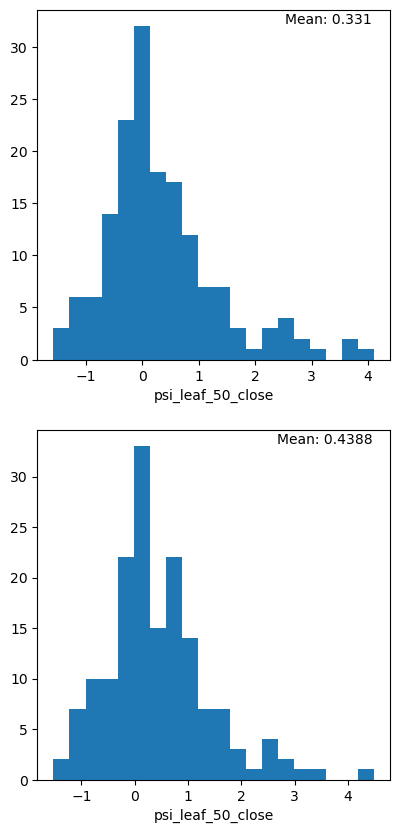

In [23]:
for var in vars:
   #if (var == 'id') | (var == 'sid'):
   #     continue        
    fig = plt.figure(figsize=(10,10))
    for sid in [1,3,4]:
        dfh = pd.DataFrame()
        dfh[var] = df_norm[df_norm['sid'] == sid][var].values - df_norm[df_norm['sid'] == 0][var].values
        ax = fig.add_subplot(2,2,sid)
        ax.hist(dfh[var], alpha=1.0, bins = 20)
        ax.set_xlabel(var)
        ax.text(0.95, 0.95, f"Mean: {np.round(dfh[var].mean(), 4)}",
        verticalalignment ='bottom',
        horizontalalignment ='right',
        transform = ax.transAxes)
    plt.savefig(f"{post_path}/sid_hist_{var}.png")
    plt.close(fig)